In [10]:
import pandas as pd
import numpy as np
# =====================================
# Helper Functions for Dataset Exploration
# =====================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

print("import succussefully")

import succussefully


In [11]:
# -------------------------------
# 1. CONFIGURATION
# -------------------------------

DATASET_PATHS = {
    "binary": "../data/merged/binary_dataset_clean.csv",
    "three_class": "../data/merged/three_class_dataset_clean.csv",
    "multi_class": "../data/merged/multi_class_dataset_clean.csv"
}

# Unified top-7 feature subset
TOP_FEATURES = [
    "R4-PM2:V",
    "R4-PM7:V",
    "R4-PM1:V",
    "R1-PM11:I",
    "R1-PM12:I",
    "R1-PA1:VH",
    "R1-PA2:VH"
]

TARGET_COL = "marker"


In [15]:
# -------------------------------
# 2. HELPER FUNCTIONS
# -------------------------------
def load_dataset(path, feature_cols, target_col):
    df = pd.read_csv(path)
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    return X, y


def stratified_70_15_15_split(X, y, random_state=42):
    # Train (70%) / Temp (30%)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=random_state
    )
    # Validation (15%) / Test (15%)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def build_models():
    models = {
        "Logistic Regression": LogisticRegression(
            max_iter=2000,
            class_weight='balanced'
        ),
        "Linear SVM": SVC(
            kernel='linear',
            class_weight='balanced',
            probability=True
        ),
        "Decision Tree": DecisionTreeClassifier(
            class_weight='balanced',
            random_state=42
        ),
        "kNN": KNeighborsClassifier(
            n_neighbors=5
        )
    }
    return models


def evaluate_model(name, model, X_train, X_test, y_train, y_test, class_names):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n===== {name} =====")

    # Metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro', zero_division=0)
    rec = recall_score(y_test, preds, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, preds, average='macro', zero_division=0)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("Macro F1:", f1_macro)

    # Handle only labels present in y_test
    labels_present = np.unique(y_test)
    names_present = [str(class_names[i]) for i in labels_present]  # ← FIXED

    print("\nClassification Report:\n")
    print(classification_report(
        y_test, preds,
        labels=labels_present,
        target_names=names_present,
        zero_division=0
    ))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds, labels=labels_present)

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap="Blues",
        xticklabels=names_present,
        yticklabels=names_present
    )
    plt.title(f"{name} - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision_macro": prec,
        "Recall_macro": rec,
        "F1_macro": f1_macro
    }



############################################################
 BASELINE EVALUATION — BINARY DATASET 
############################################################
Label mapping:
0 → Attack
1 → Natural

===== Logistic Regression =====
Accuracy: 0.6348558305690227
Precision: 0.5786798504695359
Recall: 0.5869040492540015
Macro F1: 0.5802066221953244

Classification Report:

              precision    recall  f1-score   support

      Attack       0.77      0.70      0.73      8350
     Natural       0.39      0.47      0.43      3407

    accuracy                           0.63     11757
   macro avg       0.58      0.59      0.58     11757
weighted avg       0.66      0.63      0.64     11757



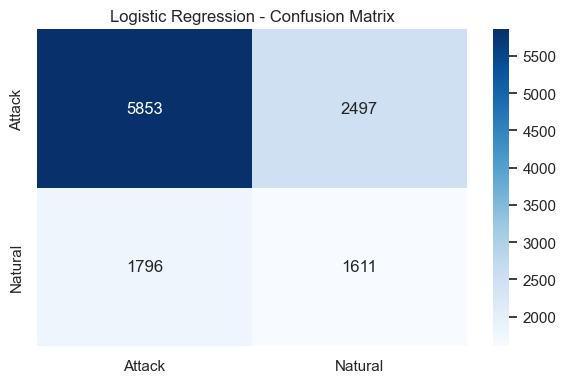


===== Linear SVM =====
Accuracy: 0.6310283235519265
Precision: 0.5766616800020159
Recall: 0.5853388321683607
Macro F1: 0.5779032769794685

Classification Report:

              precision    recall  f1-score   support

      Attack       0.76      0.69      0.73      8350
     Natural       0.39      0.48      0.43      3407

    accuracy                           0.63     11757
   macro avg       0.58      0.59      0.58     11757
weighted avg       0.66      0.63      0.64     11757



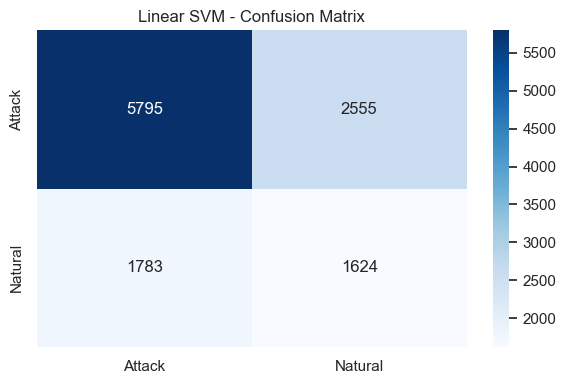


===== Decision Tree =====
Accuracy: 0.7999489665731054
Precision: 0.7572362441207813
Recall: 0.7523036580200326
Macro F1: 0.7546679730002315

Classification Report:

              precision    recall  f1-score   support

      Attack       0.85      0.87      0.86      8350
     Natural       0.66      0.64      0.65      3407

    accuracy                           0.80     11757
   macro avg       0.76      0.75      0.75     11757
weighted avg       0.80      0.80      0.80     11757



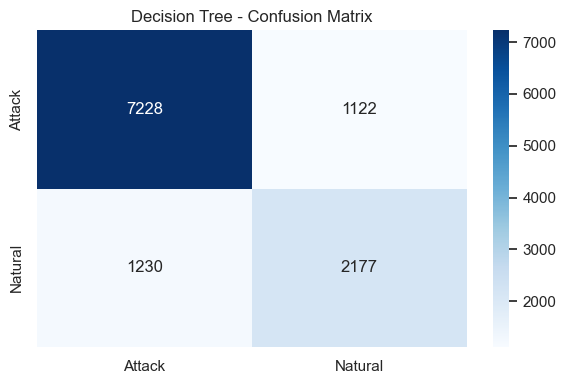


===== kNN =====
Accuracy: 0.7967168495364464
Precision: 0.7577453078252419
Recall: 0.7249209183628633
Macro F1: 0.737311243140083

Classification Report:

              precision    recall  f1-score   support

      Attack       0.83      0.90      0.86      8350
     Natural       0.68      0.55      0.61      3407

    accuracy                           0.80     11757
   macro avg       0.76      0.72      0.74     11757
weighted avg       0.79      0.80      0.79     11757



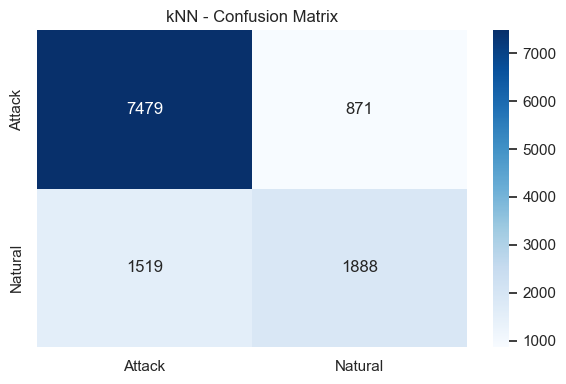

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Dataset
0,Logistic Regression,0.634856,0.578680,0.586904,0.580207,Binary
1,Linear SVM,0.631028,0.576662,0.585339,0.577903,Binary
2,Decision Tree,0.799949,0.757236,0.752304,0.754668,Binary
3,kNN,0.796717,0.757745,0.724921,0.737311,Binary


In [16]:
# ============================
# BASELINE: BINARY DATASET
# ============================

dataset_name = "binary"
path = DATASET_PATHS[dataset_name]

print("\n" + "#" * 60)
print(" BASELINE EVALUATION — BINARY DATASET ")
print("#" * 60)

# Load dataset
X, y_raw = load_dataset(path, TOP_FEATURES, TARGET_COL)

# Encode labels
le_bin = LabelEncoder()
y = le_bin.fit_transform(y_raw)
class_names_bin = le_bin.classes_

print("Label mapping:")
for i, label in enumerate(le_bin.classes_):
    print(i, "→", label)
    
# 70/15/15 split
X_train, X_val, X_test, y_train, y_val, y_test = stratified_70_15_15_split(X, y)

# Scaling
scaler_bin = StandardScaler()
X_train_scaled = scaler_bin.fit_transform(X_train)
X_test_scaled = scaler_bin.transform(X_test)

models = build_models()
binary_results = []

# Train + evaluate
for model_name, model in models.items():
    metrics = evaluate_model(
        model_name,
        model,
        X_train if model_name == "Decision Tree" else X_train_scaled,
        X_test if model_name == "Decision Tree" else X_test_scaled,
        y_train,
        y_test,
        class_names_bin
    )
    metrics["Dataset"] = "Binary"
    binary_results.append(metrics)

binary_results_df = pd.DataFrame(binary_results)
binary_results_df



############################################################
 BASELINE EVALUATION — THREE-CLASS DATASET 
############################################################

===== Logistic Regression =====
Accuracy: 0.5348303138555754
Precision: 0.41335491613583136
Recall: 0.5842052445151403
Macro F1: 0.41301199990113524

Classification Report:

              precision    recall  f1-score   support

      Attack       0.77      0.61      0.69      8350
     Natural       0.27      0.19      0.22      2746
    NoEvents       0.20      0.94      0.33       661

    accuracy                           0.53     11757
   macro avg       0.41      0.58      0.41     11757
weighted avg       0.62      0.53      0.56     11757



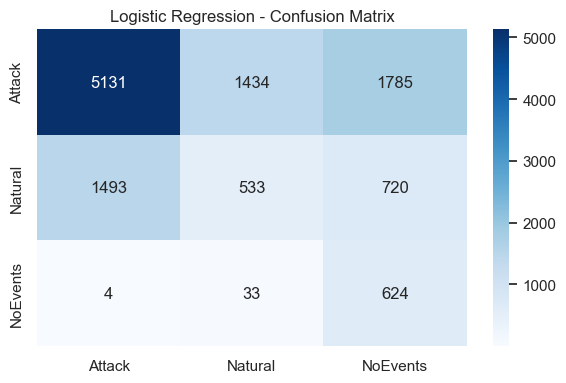


===== Linear SVM =====
Accuracy: 0.5735306625839925
Precision: 0.41184958968378743
Recall: 0.5821647657829777
Macro F1: 0.4144548671661033

Classification Report:

              precision    recall  f1-score   support

      Attack       0.77      0.69      0.73      8350
     Natural       0.25      0.12      0.17      2746
    NoEvents       0.21      0.93      0.35       661

    accuracy                           0.57     11757
   macro avg       0.41      0.58      0.41     11757
weighted avg       0.62      0.57      0.58     11757



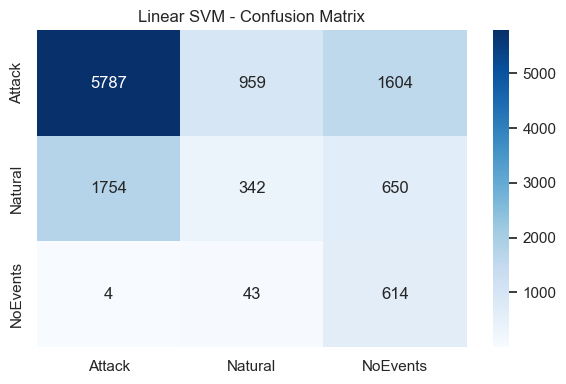


===== Decision Tree =====
Accuracy: 0.7843837713702475
Precision: 0.7379843683277075
Recall: 0.7143502955446736
Macro F1: 0.7256013112728708

Classification Report:

              precision    recall  f1-score   support

      Attack       0.85      0.86      0.86      8350
     Natural       0.58      0.56      0.57      2746
    NoEvents       0.78      0.72      0.75       661

    accuracy                           0.78     11757
   macro avg       0.74      0.71      0.73     11757
weighted avg       0.78      0.78      0.78     11757



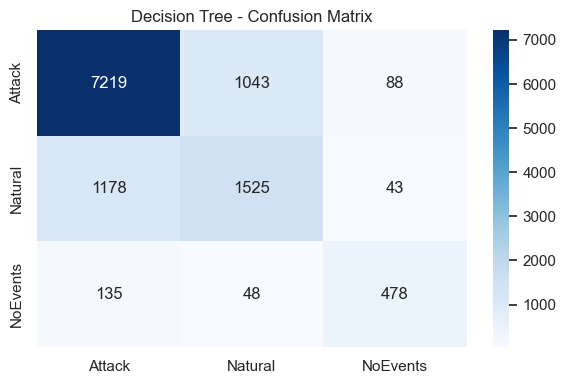


===== kNN =====
Accuracy: 0.7763034787786
Precision: 0.7308643317287515
Recall: 0.649236827489967
Macro F1: 0.6813354661764847

Classification Report:

              precision    recall  f1-score   support

      Attack       0.81      0.90      0.86      8350
     Natural       0.60      0.43      0.50      2746
    NoEvents       0.78      0.62      0.69       661

    accuracy                           0.78     11757
   macro avg       0.73      0.65      0.68     11757
weighted avg       0.76      0.78      0.76     11757



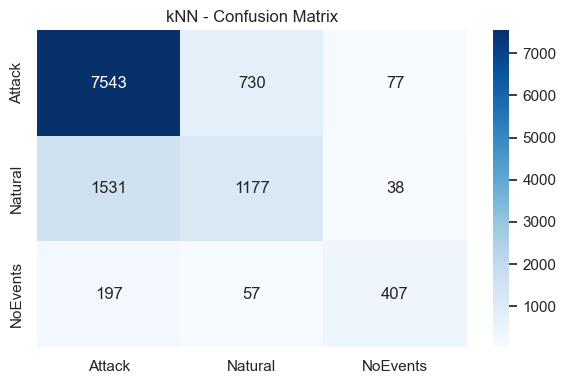

,Model,Accuracy,Precision_macro,Recall_macro,F1_macro,Dataset
0,Logistic Regression,0.534830,0.413355,0.584205,0.413012,Three-Class
1,Linear SVM,0.573531,0.411850,0.582165,0.414455,Three-Class
2,Decision Tree,0.784384,0.737984,0.714350,0.725601,Three-Class
3,kNN,0.776303,0.730864,0.649237,0.681335,Three-Class


In [17]:
# ============================
# BASELINE: THREE-CLASS DATASET
# ============================

dataset_name = "three_class"
path = DATASET_PATHS[dataset_name]

print("\n" + "#" * 60)
print(" BASELINE EVALUATION — THREE-CLASS DATASET ")
print("#" * 60)

# Load dataset
X, y_raw = load_dataset(path, TOP_FEATURES, TARGET_COL)

# Encode labels
le_three = LabelEncoder()
y = le_three.fit_transform(y_raw)
class_names_three = le_three.classes_

# Split
X_train, X_val, X_test, y_train, y_val, y_test = stratified_70_15_15_split(X, y)

# Scaling
scaler_three = StandardScaler()
X_train_scaled = scaler_three.fit_transform(X_train)
X_test_scaled = scaler_three.transform(X_test)

models = build_models()
three_results = []

# Train + evaluate
for model_name, model in models.items():
    metrics = evaluate_model(
        model_name,
        model,
        X_train if model_name == "Decision Tree" else X_train_scaled,
        X_test if model_name == "Decision Tree" else X_test_scaled,
        y_train,
        y_test,
        class_names_three
    )
    metrics["Dataset"] = "Three-Class"
    three_results.append(metrics)

three_results_df = pd.DataFrame(three_results)
three_results_df


In [ ]:
# ============================
# BASELINE: MULTI-CLASS DATASET (41 CLASSES)
# ============================

dataset_name = "multi_class"
path = DATASET_PATHS[dataset_name]

print("\n" + "#" * 60)
print(" BASELINE EVALUATION — MULTI-CLASS DATASET (41 CLASSES) ")
print("#" * 60)

# Load dataset
X, y_raw = load_dataset(path, TOP_FEATURES, TARGET_COL)

# Encode labels
le_multi = LabelEncoder()
y = le_multi.fit_transform(y_raw)
class_names_multi = le_multi.classes_

# Split
X_train, X_val, X_test, y_train, y_val, y_test = stratified_70_15_15_split(X, y)

# Scaling
scaler_multi = StandardScaler()
X_train_scaled = scaler_multi.fit_transform(X_train)
X_test_scaled = scaler_multi.transform(X_test)

models = build_models()
multi_results = []

# Train + evaluate
for model_name, model in models.items():
    metrics = evaluate_model(
        model_name,
        model,
        X_train if model_name == "Decision Tree" else X_train_scaled,
        X_test if model_name == "Decision Tree" else X_test_scaled,
        y_train,
        y_test,
        class_names_multi
    )
    metrics["Dataset"] = "Multi-Class"
    multi_results.append(metrics)

multi_results_df = pd.DataFrame(multi_results)
multi_results_df


In [ ]:
SCENARIO_LOOKUP = {
    # Natural Faults (1–6)
    1: "Fault L1 (10–19%)",
    2: "Fault L1 (20–79%)",
    3: "Fault L1 (80–90%)",
    4: "Fault L2 (10–19%)",
    5: "Fault L2 (20–79%)",
    6: "Fault L2 (80–90%)",

    # Maintenance (13–14)
    13: "Line Maintenance L1",
    14: "Line Maintenance L2",

    # Data Injection Attacks (7–12)
    7:  "Data Injection: L1 Fault 10–19% with tripping",
    8:  "Data Injection: L1 Fault 20–79% with tripping",
    9:  "Data Injection: L1 Fault 80–90% with tripping",
    10: "Data Injection: L2 Fault 10–19% with tripping",
    11: "Data Injection: L2 Fault 20–79% with tripping",
    12: "Data Injection: L2 Fault 80–90% with tripping",

    # Remote Tripping Attacks (15–20)
    15: "Remote Tripping: Command Injection R1",
    16: "Remote Tripping: Command Injection R2",
    17: "Remote Tripping: Command Injection R3",
    18: "Remote Tripping: Command Injection R4",
    19: "Remote Tripping: Command Injection R1 & R2",
    20: "Remote Tripping: Command Injection R3 & R4",

    # Relay Setting Change (21–30)
    21: "Relay Setting Change: R1 disabled (L1 10–19% fault)",
    22: "Relay Setting Change: R1 disabled (L1 20–90% fault)",
    23: "Relay Setting Change: R2 disabled (L1 10–49% fault)",
    24: "Relay Setting Change: R2 disabled (L1 50–79% fault)",
    25: "Relay Setting Change: R2 disabled (L1 80–90% fault)",
    26: "Relay Setting Change: R3 disabled (L2 10–19% fault)",
    27: "Relay Setting Change: R3 disabled (L2 20–49% fault)",
    28: "Relay Setting Change: R3 disabled (L2 50–90% fault)",
    29: "Relay Setting Change: R4 disabled (L2 10–79% fault)",
    30: "Relay Setting Change: R4 disabled (L2 80–90% fault)",

    # Relay Setting Change (two relays + fault)
    35: "Relay Setting Change: R1 & R2 disabled (L1 10–49% fault)",
    36: "Relay Setting Change: R1 & R2 disabled (L1 50–90% fault)",
    37: "Relay Setting Change: R3 & R4 disabled (L1 10–49% fault)",
    38: "Relay Setting Change: R3 & R4 disabled (L1 50–90% fault)",

    # Relay Setting Change (two relays + maintenance)
    39: "Relay Setting Change: R1 & R2 disabled during maintenance",
    40: "Relay Setting Change: R1 & R2 disabled during maintenance",

    # Normal Operation
    41: "Normal Operation (no disturbances)"
}


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------------------------
# TRAINING FUNCTIONS
# -----------------------------------------------------------

def stratified_70_15_15_split(X, y, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=random_state
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=random_state
    )
    return X_train, X_val, X_test, y_train, y_val, y_test


def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    print(f"\n===== {name} =====")
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro', zero_division=0)
    rec = recall_score(y_test, preds, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, preds, average='macro', zero_division=0)

    print("Accuracy:", acc)
    print("Precision (macro):", prec)
    print("Recall (macro):", rec)
    print("Macro F1:", f1_macro)

    print("\nClassification Report:")
    print(classification_report(y_test, preds, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision_macro": prec,
        "Recall_macro": rec,
        "F1_macro": f1_macro
    }


# -----------------------------------------------------------
# MAIN TRAINING LOOP FOR ALL DATASETS
# -----------------------------------------------------------

results_summary = []

for dataset_name, df in cleaned_datasets.items():

    print("\n============================================================")
    print(f"                 TRAINING FOR DATASET: {dataset_name}")
    print("============================================================\n")

    # --- FIX 1: Remove columns that contain any strings ---
    non_numeric_cols = df.select_dtypes(exclude=['number']).columns
    if len(non_numeric_cols) > 0:
        print("Dropping non-numeric columns:", list(non_numeric_cols))
    df = df.drop(columns=non_numeric_cols)

    # --- FIX 2: Ensure label column is extracted safely ---
    y = df["label"]
    X = df.drop(columns=["label"])

    # --- FIX 3: All remaining data MUST be numeric now ---
    assert all([np.issubdtype(dtype, np.number) for dtype in X.dtypes]), "Non-numeric still exists!"

    # Split data
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_70_15_15_split(X, y)

    models = {
        "Logistic Regression": LogisticRegression(max_iter=200),
        "SVM (RBF)": SVC(kernel='rbf'),
        "Decision Tree": DecisionTreeClassifier(),
        "KNN": KNeighborsClassifier()
    }

    for model_name, model in models.items():
        res = evaluate_model(
            f"{dataset_name} - {model_name}",
            model,
            X_train, X_test, y_train, y_test
        )
        results_summary.append(res)


    # SPLIT
    X_train, X_val, X_test, y_train, y_val, y_test = stratified_70_15_15_split(X, y)

    # MODELS TO TRAIN
    models = {
        "Logistic Regression": LogisticRegression(max_iter=200, n_jobs=-1),
        "SVM (RBF Kernel)": SVC(kernel='rbf'),
        "Decision Tree": DecisionTreeClassifier(),
        "KNN": KNeighborsClassifier()
    }

    # TRAIN MODELS
    for model_name, model in models.items():
        res = evaluate_model(
            f"{dataset_name} - {model_name}",
            model,
            X_train, X_test, y_train, y_test
        )
        results_summary.append(res)

print("\n====================== FINAL SUMMARY ======================\n")
for r in results_summary:
    print(r)


NameError: name 'cleaned_datasets' is not defined

In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/merged/multi_class_dataset_clean.csv")

print("=== CHECKING RAW DATASET FOR NaN, inf, -inf ===")
print("Total NaN:", df.isna().sum().sum())
print("Total inf:", np.isinf(df.values).sum())
print("Total -inf:", np.isneginf(df.values).sum())

inf_cols = df.columns[np.isinf(df).any()].tolist()
print("Columns with inf values:", inf_cols)
inf_count_per_col = np.isinf(df).sum()
print(inf_count_per_col[inf_count_per_col > 0])



=== CHECKING RAW DATASET FOR NaN, inf, -inf ===
Total NaN: 0
Total inf: 10906
Total -inf: 0
Columns with inf values: ['R1-PA:Z', 'R2-PA:Z', 'R3-PA:Z', 'R4-PA:Z']
R1-PA:Z    2877
R2-PA:Z    2607
R3-PA:Z    2633
R4-PA:Z    2789
dtype: int64
